<a href="https://colab.research.google.com/github/peculab/UW_AgenticAI/blob/main/Trading_AgenticAI_GAF_CNN_DQN_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9 Report: 
## Final Project Codebase

### Group Members:
- Eric Hur
- Leo Alburg

**Extends** [Chen & Tsai (2020)](https://doi.org/10.1186/s40854-020-00187-0) and [peculab/UW_AgenticAI](https://github.com/peculab/UW_AgenticAI) by Prof. Yun-Cheng Tsai.  

## Introduction & Motivation

<!-- INSERT: Agentic workflow diagram and financial pipeline visual here -->
Financial markets generate vast amounts of price and volume data every day. 
Traditionally, traders relied on manual chart reading and hand-coded rule systems 
to identify candlestick patterns — a technical analysis method dating back to 
17th century Japanese rice trading. While effective, this approach is slow, 
subjective, and difficult to scale.

This project applies the GAF-CNN pipeline from Chen & Tsai (2020) to automate 
candlestick pattern recognition on SPY — the S&P 500 ETF and the broadest single 
proxy for the US equity market. By encoding price time series as Gramian Angular 
Field (GAF) images, we allow a CNN to learn pattern structure the same way the 
human eye recognizes visual shapes — but faster, consistently, and at scale.

Downstream, a Deep Q-Network (DQN) uses the CNN's pattern classifications to 
retrospectively learn what trading decisions would have been most profitable 
given historical SPY data from 2018 to 2026. This is not a price prediction 
system — it is a hindsight analysis tool that asks: *"given what we now know 
happened, what decision rule would have performed best?"* An agentic layer then 
wraps the pipeline with risk review and human-readable explanation, making the 
system auditable and interpretable.

Our contribution extends this pipeline by adding trading volume as a 5th GAF 
channel alongside the standard CULR price features. Volume directly reflects 
investor participation — unlike forex pairs where volume is ambiguous, SPY 
volume is a clean demand signal. We test whether this additional channel improves 
candlestick pattern classification accuracy through a three-experiment ablation study

---

## Experimental Setup

**Core question:** Does adding trading volume as a 5th GAF channel improve candlestick pattern classification on SPY?

| Exp | Input | Purpose |
|---|---|---|
| 1 | CULR (4ch) | Baseline — replicates Chen & Tsai on SPY |
| 2 | CULR + Volume (5ch) | Core claim — does volume help? |
| 3 | Volume only (1ch) | Ablation — volume contribution alone |

> Educational use only. Not investment advice.

<!-- ARCHIVED: Original demo flow and pipeline steps
1. Encode OHLC candlestick windows as GAF images and train a CNN to classify the current signal.
2. Train a compact Deep Q Network to choose long / flat / short actions.
3. Apply the Lab 7 Agentic AI idea by wrapping the workflow in SignalAnalyst, StrategyAgent, RiskManager, and InterfaceAgent roles.

Demo Flow:
0-2 min  | Load FX OHLC data and introduce candlestick-as-image modeling
2-5 min  | Build CULR channels and GAF image encoding
5-8 min  | Use a CNN to classify bullish / neutral / bearish signals
8-12 min | Use DQN to select short / flat / long actions
12-15 min| Use Agentic AI roles to generate an entry/exit recommendation
-->

## Other settings/ Utilities


#### Environmental setup
The cell below lists the packages needed by the project. \
Set `RUN_INSTALL = True` if the current runtime does not already have these packages.

In [4]:
from pathlib import Path
import subprocess
import sys
import os

REQUIREMENTS = [
    line.strip() for line in """
tensorflow==2.21.0
yfinance==1.3.0
scikit-learn==1.7.2
matplotlib==3.10.9
pandas==2.3.3
numpy==2.2.6
google-genai
""".strip().splitlines()
]

print("Final Project package requirements:")
print("\n".join(REQUIREMENTS))

RUN_INSTALL = False  # Change to True to install packages in the current runtime.

if RUN_INSTALL:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIREMENTS])
    print("Package installation complete. Runtime restart may be needed if older packages were already loaded.")
else:
    print("Local runtime detected; skipping pip install. Set RUN_INSTALL = True to install anyway.")

_save_named_results(globals(), cell_idx=3)



Final Project package requirements:
tensorflow==2.21.0
yfinance==1.3.0
scikit-learn==1.7.2
matplotlib==3.10.9
pandas==2.3.3
numpy==2.2.6
google-genai
Local runtime detected; skipping pip install. Set RUN_INSTALL = True to install anyway.


In [38]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ── Plotly Renderer ───────────────────────────────────────────
try:
    import plotly.io as _pio
    _pio.renderers.default = "notebook_connected"
except Exception as e:
    print(f"Plotly renderer setup skipped: {e}")


In [20]:
def add_continuous_time_axis(fig, times, row=None, col=None, max_ticks=10):
    """Format x-axis with readable datetime labels for Plotly figures.
    
    Args:
        fig: Plotly figure object.
        times: Array of datetime values for x-axis labels.
        row (int): Subplot row (None for single plot).
        col (int): Subplot column (None for single plot).
        max_ticks (int): Maximum number of x-axis tick labels.
    
    Returns:
        fig: Updated Plotly figure.
    """
    times = pd.to_datetime(pd.Index(times))
    n = len(times)
    if n == 0:
        return fig
    step = max(1, n // max_ticks)
    tickvals = list(range(0, n, step))
    if tickvals[-1] != n - 1:
        tickvals.append(n - 1)
    ticktext = [times[i].strftime("%Y-%m-%d") for i in tickvals]
    kwargs = {
        "tickmode": "array",
        "tickvals": tickvals,
        "ticktext": ticktext,
        "rangeslider": {"visible": False},
        "title_text": "Date",
    }
    if row is None:
        fig.update_xaxes(**kwargs)
    else:
        fig.update_xaxes(row=row, col=col, **kwargs)
    return fig


def plot_price_candles_continuous(price_df, title):
    """Plot interactive candlestick chart using Plotly.
    
    Args:
        price_df (pd.DataFrame): OHLC DataFrame with DatetimeIndex.
        title (str): Chart title.
    
    Returns:
        pd.DataFrame: Input price_df unchanged.
    """
    price_df  = price_df[["Open", "High", "Low", "Close"]].dropna().copy()
    x         = np.arange(len(price_df))
    time_text = pd.to_datetime(price_df.index).strftime("%Y-%m-%d")
    fig = go.Figure(data=[go.Candlestick(
        x=x,
        open=price_df["Open"],
        high=price_df["High"],
        low=price_df["Low"],
        close=price_df["Close"],
        increasing_line_color="#2ca02c",
        decreasing_line_color="#d62728",
        text=[
            f"Date: {t}<br>Open: {o:.2f}<br>High: {h:.2f}<br>Low: {l:.2f}<br>Close: {c:.2f}"
            for t, o, h, l, c in zip(time_text, price_df["Open"], price_df["High"], price_df["Low"], price_df["Close"])
        ],
        hoverinfo="text",
        name="OHLC"
    )])
    fig.update_layout(
        title=f"{title} ({len(price_df):,} bars)",
        yaxis_title="Price (USD)",
        height=560,
        hovermode="x unified",
        margin={"l": 55, "r": 30, "t": 70, "b": 70},
        showlegend=False,
    )
    add_continuous_time_axis(fig, price_df.index)
    show_plot(fig)
    return price_df

## 1. Prepare Data



### 1.1 SPY Datasets

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ───────────────────────────────────────────
SEED = 7
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ── Data Config ───────────────────────────────────────────────
TICKER   = "SPY"
INTERVAL = "1d"
FREQ     = "D"

# ── Model Config ──────────────────────────────────────────────
WINDOW   = 10
HORIZON  = 8       # bars ahead for DQN reward calculation
COST     = 0.00002 # transaction cost per trade for DQN


# ── Experiment Control ────────────────────────────────────────
USE_PRETRAINED_CNN         = False  # always False — training from scratch
EVALUATE_PROXY_RULE_LABELS = False
ADD_VOLUME                 = False  # Exp1=False, Exp2=True, Exp3=volume only


# ── Dataset Paths ─────────────────────────────────────────────
NOTEBOOK_DIR   = Path().resolve()
SPY_DAILY      = NOTEBOOK_DIR / "Dataset" / "spy_daily.csv"
SPY_HOURLY     = NOTEBOOK_DIR / "Dataset" / "spy_hourly.csv"
SPY_5MIN       = NOTEBOOK_DIR / "Dataset" / "spy_5min.csv"
ACTIVE_DATASET = SPY_DAILY


# ── Pattern Labels ────────────────────────────────────────────
pattern_class_names = [
    "doji",
    "hammer",
    "hanging_man",
    "shooting_star",
    "bullish_engulfing",
    "bearish_engulfing",
    "morning_star",
    "evening_star",
    "unknown",
]
class_names = pattern_class_names
signal_names = ["bearish", "neutral", "bullish"]
pattern_to_bias = {
    "doji": "neutral",
    "hammer": "bullish",
    "hanging_man": "bearish",
    "shooting_star": "bearish",
    "bullish_engulfing": "bullish",
    "bearish_engulfing": "bearish",
    "morning_star": "bullish",
    "evening_star": "bearish",
    "unknown": "neutral",
}
bias_to_signal_id = {"bearish": 0, "neutral": 1, "bullish": 2}
pattern_bias_ids = np.array([bias_to_signal_id[pattern_to_bias[name]] for name in pattern_class_names])


# ── DQN Action Space ──────────────────────────────────────────
action_names = ["short", "flat", "long"]
action_to_position = np.array([-1, 0, 1], dtype=np.float32)



Training and validation use two separate datasets following the two-phase 
approach of Chen & Tsai (2020):

- **Training:** Synthetic SPY-like OHLCV data generated via Geometric Brownian 
Motion (GBM). GBM is used because real SPY data contains too few labeled pattern 
examples (e.g. only ~24 Hammer occurrences in 8 years) to train a CNN effectively. 
GBM produces thousands of statistically realistic price paths under known parameters, 
serving as the simulation ground truth — analogous to Monte Carlo in physics.

- **Validation:** Real SPY daily OHLCV data (2018-01-01 to 2026-04-30) loaded 
from local CSV. This is the experimental data that tests whether the 
simulation-trained model generalizes to real market conditions.

The CSV is required — if loading fails, check that `Dataset/spy_daily.csv` 
exists in the same directory as this notebook.


In [32]:
def make_synthetic_ohlc(n=10000, start=350, use_volume=ADD_VOLUME):
    """Generate synthetic SPY-like OHLCV data using Geometric Brownian Motion.
    
    Used as training data because real SPY contains too few labeled pattern
    examples to train a CNN effectively. GBM produces statistically realistic
    price paths under known parameters — analogous to Monte Carlo in physics.
    
    Args:
        n (int): Number of bars to generate. Default 5000.
        start (float): Starting price level in dollars. Default 500 (~SPY price).
        use_volume (bool): If True, generate volume correlated with price moves.
                           If False, volume = 1 (placeholder).
    
    Returns:
        pd.DataFrame: Synthetic OHLCV DataFrame with daily DatetimeIndex.
    """
    rng        = np.random.default_rng(SEED)
    volatility = 0.012
    drift      = 0.0003
    returns    = rng.normal(drift, volatility, n) + 0.0002 * np.sin(np.arange(n) / 25)
    close      = start * np.exp(np.cumsum(returns))
    
    # Overnight gap model (SPY-realistic, helps multi-bar patterns)
    gap    = rng.normal(0, 0.004, n)
    open_  = np.r_[close[0], close[:-1] * np.exp(gap[1:])]
    
    upper_spread = rng.uniform(0.002, 0.015, n) * close
    lower_spread = rng.uniform(0.002, 0.015, n) * close
    
    # Bias ~15% of bars toward hammer/hanging_man geometry
    hammer_mask = rng.random(n) < 0.15
    lower_spread[hammer_mask] = rng.uniform(0.008, 0.020, hammer_mask.sum()) * close[hammer_mask]
    upper_spread[hammer_mask] = rng.uniform(0.0005, 0.002, hammer_mask.sum()) * close[hammer_mask]
    
    high = np.maximum(open_, close) + upper_spread
    low  = np.minimum(open_, close) - lower_spread
    
    if use_volume:
        base_vol = np.exp(rng.normal(np.log(80e6), 0.3, n))
        volume   = base_vol * (1 + 5 * np.abs(returns))
    else:
        volume = np.ones(n)

    idx = pd.date_range(end=pd.Timestamp.utcnow(), periods=n, freq=FREQ)
    return pd.DataFrame(
        {"Open": open_, "High": high, "Low": low, "Close": close, "Volume": volume},
        index=idx
    )


def load_ohlc():
    """Load real SPY OHLCV data from local CSV for validation.
    
    Loads from ACTIVE_DATASET path configured relative to the notebook
    directory using pathlib — cross-platform compatible (Windows/Mac/Linux).
    No fallback — real data is required for validation.
    
    Returns:
        pd.DataFrame: Real SPY OHLCV DataFrame with DatetimeIndex.
    
    Raises:
        FileNotFoundError: If CSV not found at ACTIVE_DATASET path.
    """
    df = pd.read_csv(ACTIVE_DATASET, index_col=0, parse_dates=True, skiprows=[1, 2])
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    print(f"Loaded {len(df)} rows from {ACTIVE_DATASET.name}")
    return df


# ── Load datasets ─────────────────────────────────────────────
synthetic = make_synthetic_ohlc()
print(f"Synthetic training data: {len(synthetic)} bars")
print(f"Synthetic price range:   ${synthetic['Close'].min():.2f} — ${synthetic['Close'].max():.2f}")
print(f"Synthetic volume mean:   {synthetic['Volume'].mean():.0f}")
print()

raw = load_ohlc()
print(f"Real validation data:    {len(raw)} bars")
print(f"Real price range:        ${raw['Close'].min():.2f} — ${raw['Close'].max():.2f}")
print(f"Real volume mean:        {raw['Volume'].mean():.0f}")
print()

print("=== Synthetic tail ===")
display(synthetic.tail())
print("=== Real SPY tail ===")
display(raw.tail())

Synthetic training data: 10000 bars
Synthetic price range:   $143.36 — $1934.03
Synthetic volume mean:   1

Loaded 2092 rows from spy_daily.csv
Real validation data:    2092 bars
Real price range:        $204.94 — $715.17
Real volume mean:        81001467

=== Synthetic tail ===


,Open,High,Low,Close,Volume
2026-05-20 01:56:57.871138+00:00,1592.300503,1644.066894,1587.249641,1632.409030,1.0
2026-05-21 01:56:57.871138+00:00,1640.365975,1652.449298,1612.720113,1621.103130,1.0
2026-05-22 01:56:57.871138+00:00,1615.668168,1630.941212,1602.326276,1625.596212,1.0
2026-05-23 01:56:57.871138+00:00,1634.166153,1658.584098,1621.991090,1650.266111,1.0
2026-05-24 01:56:57.871138+00:00,1646.978662,1655.752284,1609.443740,1615.657595,1.0


=== Real SPY tail ===


,Open,High,Low,Close,Volume
Price,,,,,
2026-04-23,709.500000,712.359985,702.280029,708.450012,56174000
2026-04-24,710.750000,714.469971,709.010010,713.940002,45182000
2026-04-27,713.169983,715.630005,712.299988,715.169983,33135900
2026-04-28,711.820007,712.880005,709.250000,711.690002,43117400
2026-04-29,711.000000,712.200012,708.369995,711.580017,41859200


### 1.2. Candlestick Window -> GAF Image
Each 10-bar OHLCV window is converted into a 2D image using the Gramian Angular 
Field (GAF) encoding from Wang & Oates (2015). \
This bridges the gap between 1D time series and 2D image classification — allowing a CNN to detect candlestick 
patterns the same way the human eye recognizes visual shapes.


**Encoding pipeline per window:**
1. Extract CULR features from OHLC: Close, Upper shadow, Lower shadow, Real body
2. Optionally append Volume as a 5th channel (Experiments 2 and 3)
3. Normalize each channel to [0, 1]
4. Convert to polar coordinates via arccos
5. Build 10×10 GASF matrix: pixel $(i,j) = cos(φᵢ + φⱼ)$
6. Stack all channels → input shape (10, 10, 4) or (10, 10, 5)

**Rule-Based Pattern Labeling (Bulkowski Encyclopedia):**

Pattern labels are assigned by a rule-based detector implementing candlestick 
definitions from Bulkowski's *Encyclopedia of Candlestick Charts* (2012). These 
hand-coded geometric rules serve as the ground truth for CNN training — analogous 
to theoretical definitions in a physics simulation. The CNN does not learn what 
patterns "truly mean" in the market; it learns to recognize the visual structure 
of patterns as mathematically defined by the encyclopedia.

This two-phase approach mirrors Monte Carlo methodology in physics:
- **Simulation phase:** GBM generates synthetic price paths → rules label patterns → CNN trains on thousands of examples
- **Experimental phase:** Real SPY data → same rules label patterns → trained CNN is evaluated against reality

**The three experiment configurations:**

| Exp | Channels | Input Shape |
|---|---|---|
| 1 | CULR | (10, 10, 4) |
| 2 | CULR + Volume | (10, 10, 5) |
| 3 | Volume only | (10, 10, 1) |

In [33]:
# ── Feature Engineering ───────────────────────────────────────

def ohlc_to_culr(ohlc):
    """Convert raw OHLC prices to CULR candlestick features.
    
    CULR encodes the shape of a candlestick rather than raw price levels,
    making features more visually intuitive and reducing redundancy between
    channels when encoded as GAF images.
    
    Args:
        ohlc (np.ndarray): Array of shape (n, 4) with columns [Open, High, Low, Close].
    
    Returns:
        np.ndarray: Array of shape (n, 4) with columns:
            - Close:       closing price
            - Upper shadow: High - max(Open, Close)
            - Lower shadow: min(Open, Close) - Low
            - Real body:   Close - Open
    """
    o, h, l, c = ohlc[:, 0], ohlc[:, 1], ohlc[:, 2], ohlc[:, 3]
    upper     = h - np.maximum(o, c)
    lower     = np.minimum(o, c) - l
    real_body = c - o
    return np.stack([c, upper, lower, real_body], axis=1)


# ── GAF Encoding ──────────────────────────────────────────────

def ts_to_gasf(ts):
    """Encode a 1D time series as a Gramian Angular Summation Field (GASF) matrix.
    
    Implements Wang & Oates (2015):
    1. Normalize to [0, 1]
    2. Convert to polar angle via arccos
    3. Build symmetric matrix: GASF[i,j] = cos(φᵢ + φⱼ)
    
    Args:
        ts (np.ndarray): 1D time series of length n.
    
    Returns:
        np.ndarray: Symmetric GASF matrix of shape (n, n).
    """
    ts     = np.asarray(ts, dtype=np.float32)
    lo, hi = np.min(ts), np.max(ts)
    scaled = np.zeros_like(ts) if np.isclose(lo, hi) else (ts - lo) / (hi - lo)
    scaled = np.clip(scaled, 0, 1)
    phi    = np.arccos(scaled)
    return np.cos(phi[:, None] + phi[None, :]).astype(np.float32)


def window_to_gaf(window_ohlc, window_volume=None):
    """Convert a single OHLCV window into a stacked GAF image.
    
    Each feature channel is independently encoded as a GASF matrix
    and stacked along the last axis.
    
    Args:
        window_ohlc (np.ndarray): OHLC array of shape (WINDOW, 4).
        window_volume (np.ndarray): Volume array of shape (WINDOW,).
                                    Only used when ADD_VOLUME=True.
    
    Returns:
        np.ndarray: Stacked GAF image of shape (WINDOW, WINDOW, n_channels)
            - n_channels = 4 (CULR only)
            - n_channels = 5 (CULR + Volume, Exp 2)
            - n_channels = 1 (Volume only, Exp 3)
    """
    culr     = ohlc_to_culr(window_ohlc)
    channels = [ts_to_gasf(culr[:, i]) for i in range(4)]
    if window_volume is not None and ADD_VOLUME:
        channels.append(ts_to_gasf(window_volume))
    return np.stack(channels, axis=-1)


# ── Rule-Based Pattern Labeler (Bulkowski Encyclopedia) ───────

def _candle_parts(row):
    """Extract geometric properties from a single candlestick row.
    
    Args:
        row (pd.Series): Single row with Open, High, Low, Close columns.
    
    Returns:
        tuple: (open, high, low, close, body, candle_range, upper_shadow, lower_shadow)
    """
    o, h, l, c  = float(row["Open"]), float(row["High"]), float(row["Low"]), float(row["Close"])
    body         = abs(c - o)
    candle_range = max(h - l, 1e-8)
    upper_shadow = h - max(o, c)
    lower_shadow = min(o, c) - l
    return o, h, l, c, body, candle_range, upper_shadow, lower_shadow


def label_candlestick_pattern(window_df):
    """Assign a candlestick pattern label to a 10-bar window using rule-based detection.
    
    Rules follow Bulkowski's Encyclopedia of Candlestick Charts (2012) and
    The Major Candlestick Signals (Bigalow 2014). These rules serve as the
    ground truth labels for CNN training — analogous to theoretical definitions
    in a physics simulation.
    
    Patterns detected (in priority order):
        Single-bar:  doji, hammer, hanging_man, shooting_star
        Two-bar:     bullish_engulfing, bearish_engulfing
        Three-bar:   morning_star, evening_star
        Default:     unknown
    
    Args:
        window_df (pd.DataFrame): 10-bar window with Open, High, Low, Close columns.
    
    Returns:
        dict: {
            'pattern':  pattern name string,
            'label_id': integer class index,
            'bias':     'bullish' | 'bearish' | 'neutral',
            'reason':   plain English explanation of the matched rule
        }
    """
    candles      = window_df[["Open", "High", "Low", "Close"]]
    last         = candles.iloc[-1]
    o, h, l, c, body, candle_range, upper_shadow, lower_shadow = _candle_parts(last)
    body_ratio   = body / candle_range
    recent_close = candles["Close"].tail(min(len(candles), 6)).values.astype(float)
    trend        = recent_close[-1] - recent_close[0] if len(recent_close) >= 2 else 0.0

    pattern = "unknown"
    reason  = "No 8-pattern rule matched, so the sample is labeled unknown."

    # ── Single-bar patterns ───────────────────────────────────
    if body_ratio < 0.10:
        pattern = "doji"
        reason  = "Open and close are very close relative to the high-low range."
        
    elif lower_shadow >= 2.0 * max(body, 1e-8) and upper_shadow <= 0.6 * max(body, 1e-8):
        pattern = "hammer" if trend < 0 else "hanging_man"
        reason  = "Long lower shadow after a recent decline." if trend < 0 else "Long lower shadow after a flat/upward recent move."
        
    elif upper_shadow >= 2.0 * max(body, 1e-8) and lower_shadow <= 0.6 * max(body, 1e-8):
        pattern = "shooting_star"
        reason  = "Long upper shadow with the real body near the low."

    # ── Two-bar patterns ──────────────────────────────────────
    if len(candles) >= 2:
        prev = candles.iloc[-2]
        po, ph, pl, pc, prev_body, prev_range, _, _ = _candle_parts(prev)
        prev_bear = pc < po
        prev_bull = pc > po
        curr_bull = c > o
        curr_bear = c < o
        
        if prev_bear and curr_bull and o <= pc and c >= po:
            pattern = "bullish_engulfing"
            reason  = "Latest bullish body engulfs the previous bearish body."
            
        elif prev_bull and curr_bear and o >= pc and c <= po:
            pattern = "bearish_engulfing"
            reason  = "Latest bearish body engulfs the previous bullish body."

    # ── Three-bar patterns ────────────────────────────────────
    if len(candles) >= 3:
        c1, c2, c3                          = candles.iloc[-3], candles.iloc[-2], candles.iloc[-1]
        o1, h1, l1, cl1, b1, r1, _, _      = _candle_parts(c1)
        o2, h2, l2, cl2, b2, r2, _, _      = _candle_parts(c2)
        o3, h3, l3, cl3, b3, r3, _, _      = _candle_parts(c3)
        midpoint_1                           = (o1 + cl1) / 2
        small_middle                         = b2 / max(r2, 1e-8) < 0.35
        
        if cl1 < o1 and small_middle and cl3 > o3 and cl3 > midpoint_1:
            pattern = "morning_star"
            reason  = "Bearish candle, small indecision candle, then bullish recovery above midpoint."
            
        elif cl1 > o1 and small_middle and cl3 < o3 and cl3 < midpoint_1:
            pattern = "evening_star"
            reason  = "Bullish candle, small indecision candle, then bearish drop below midpoint."

    bias = pattern_to_bias[pattern]
    return {"pattern": pattern, "label_id": pattern_class_names.index(pattern), "bias": bias, "reason": reason}


def detect_candlestick_pattern(window_df):
    """Wrapper for label_candlestick_pattern for use in inference pipeline."""
    return label_candlestick_pattern(window_df)


def pattern_probs_to_signal_probs(pattern_probs):
    """Aggregate 9-class pattern probabilities into 3-class bias signal.
    
    Maps CNN pattern outputs to bearish/neutral/bullish using pattern_to_bias.
    Used by DQN state construction and risk agent.
    
    Args:
        pattern_probs (np.ndarray): Shape (n_samples, 9) CNN output probabilities.
    
    Returns:
        np.ndarray: Shape (n_samples, 3) signal probabilities [bearish, neutral, bullish].
    """
    pattern_probs = np.asarray(pattern_probs, dtype=np.float32)
    signal_probs  = np.zeros((pattern_probs.shape[0], len(signal_names)), dtype=np.float32)
    
    for pattern_id, signal_id in enumerate(pattern_bias_ids):
        signal_probs[:, signal_id] += pattern_probs[:, pattern_id]
    return signal_probs


# ── Supervised Dataset Builder ────────────────────────────────

def make_supervised_dataset(df, window=WINDOW, horizon=HORIZON):
    """Build labeled GAF image dataset from OHLCV DataFrame.
    
    Slides a window of size WINDOW across the DataFrame, encodes each
    window as a GAF image, and assigns a candlestick pattern label using
    the rule-based detector.
    
    Args:
        df (pd.DataFrame): OHLCV DataFrame with DatetimeIndex.
        window (int): Number of bars per GAF image. Default WINDOW=10.
        horizon (int): Bars ahead for future return calculation (DQN reward). Default HORIZON=8.
    
    Returns:
        tuple:
            X (np.ndarray):              GAF images, shape (n_samples, WINDOW, WINDOW, n_channels)
            y (np.ndarray):              Pattern label IDs, shape (n_samples,)
            times (np.ndarray):          Timestamps of last bar in each window
            future_returns (np.ndarray): Future returns for DQN reward calculation
            pattern_label_table (pd.DataFrame): Human-readable label log with pattern, bias, reason
    """
    ohlc   = df[["Open", "High", "Low", "Close"]].values.astype(np.float32)
    volume = df["Volume"].values.astype(np.float32)
    close  = df["Close"].values.astype(np.float32)

    X, y, times, future_returns, pattern_rows = [], [], [], [], []

    for end in range(window - 1, len(df) - horizon):
        start      = end - window + 1
        window_df  = df.iloc[start:end + 1][["Open", "High", "Low", "Close"]]
        label_info = label_candlestick_pattern(window_df)
        future_ret = (close[end + horizon] - close[end]) / close[end]
        window_vol = volume[start:end + 1] if ADD_VOLUME else None

        X.append(window_to_gaf(ohlc[start:end + 1], window_vol))
        y.append(label_info["label_id"])
        times.append(df.index[end])
        future_returns.append(future_ret)
        pattern_rows.append({
            "time":    df.index[end],
            "pattern": label_info["pattern"],
            "bias":    label_info["bias"],
            "reason":  label_info["reason"]
        })

    return (
        np.array(X),
        np.array(y),
        np.array(times),
        np.array(future_returns),
        pd.DataFrame(pattern_rows)
    )


# ── Build datasets ────────────────────────────────────────────
X_train, y_train, times_train, future_returns_train, pattern_label_train = make_supervised_dataset(synthetic)
X_val,   y_val,   times_val,   future_returns_val,   pattern_label_val   = make_supervised_dataset(raw)

print("=== Training Dataset (Synthetic GBM) ===")
print(f"X shape:            {X_train.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(pattern_label_train["pattern"].value_counts())

print()
print("=== Validation Dataset (Real SPY) ===")
print(f"X shape:            {X_val.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(pattern_label_val["pattern"].value_counts())

=== Training Dataset (Synthetic GBM) ===
X shape:            (9983, 10, 10, 4)
Label distribution: {np.int64(0): np.int64(1107), np.int64(1): np.int64(176), np.int64(2): np.int64(168), np.int64(3): np.int64(33), np.int64(4): np.int64(466), np.int64(5): np.int64(469), np.int64(6): np.int64(818), np.int64(7): np.int64(815), np.int64(8): np.int64(5931)}
pattern
unknown              5931
doji                 1107
morning_star          818
evening_star          815
bearish_engulfing     469
bullish_engulfing     466
hammer                176
hanging_man           168
shooting_star          33
Name: count, dtype: int64

=== Validation Dataset (Real SPY) ===
X shape:            (2075, 10, 10, 4)
Label distribution: {np.int64(0): np.int64(197), np.int64(1): np.int64(24), np.int64(2): np.int64(48), np.int64(3): np.int64(28), np.int64(4): np.int64(57), np.int64(5): np.int64(60), np.int64(6): np.int64(130), np.int64(7): np.int64(115), np.int64(8): np.int64(1416)}
pattern
unknown              1416

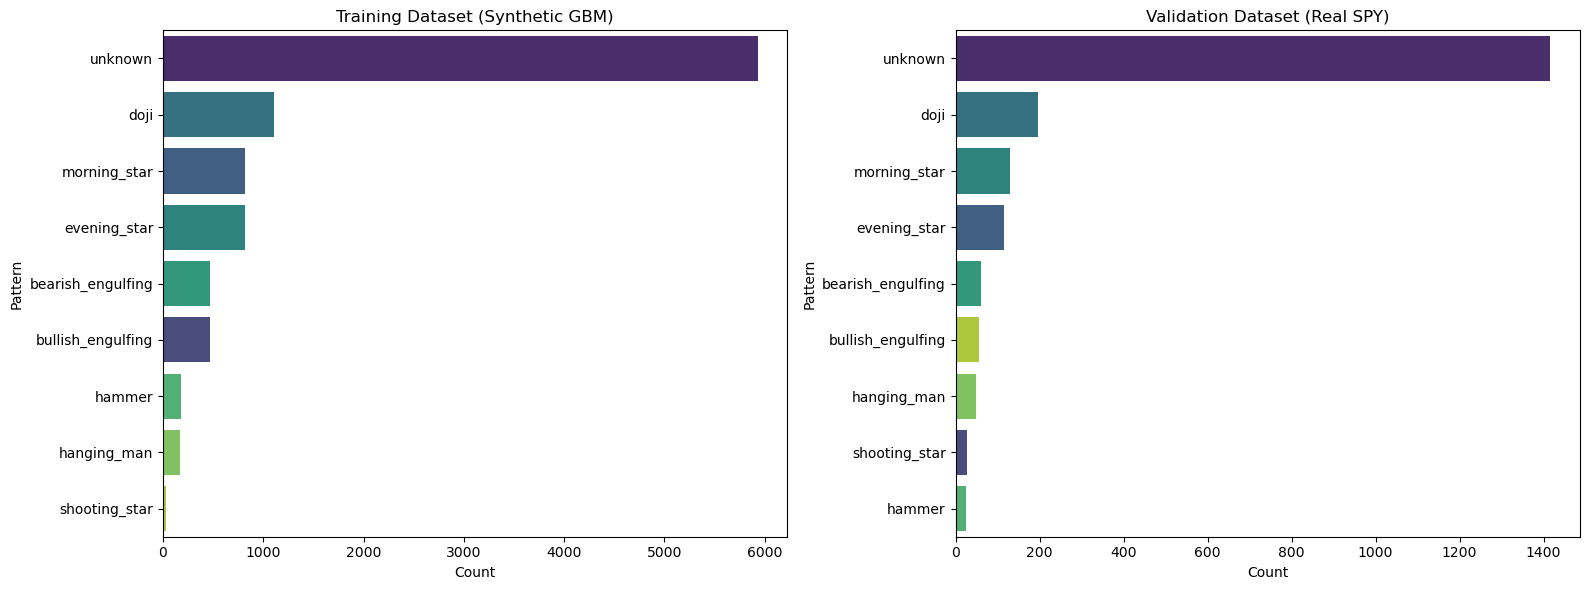

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, table, title in zip(
    axes,
    [pattern_label_train, pattern_label_val],
    ["Training Dataset (Synthetic GBM)", "Validation Dataset (Real SPY)"]
):
    sns.countplot(
        y='pattern', data=table,
        order=table['pattern'].value_counts().index,
        hue='pattern', legend=False,
        palette='viridis', ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Pattern')

plt.tight_layout()
plt.show()

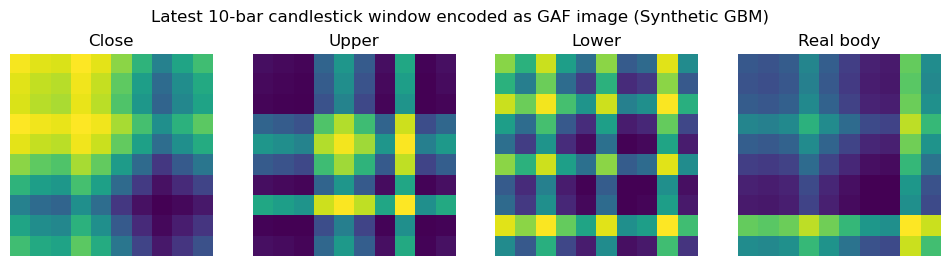

In [37]:
n_channels = 5 if ADD_VOLUME else 4
channel_names = ["Close", "Upper", "Lower", "Real body", "Volume"] if ADD_VOLUME else ["Close", "Upper", "Lower", "Real body"]

fig, axes = plt.subplots(1, n_channels, figsize=(15, 3) if ADD_VOLUME else (12, 3))
for i, name in enumerate(channel_names):
    axes[i].imshow(X_train[-1, :, :, i], cmap="viridis", vmin=-1, vmax=1)
    axes[i].set_title(name)
    axes[i].axis("off")
    
plt.suptitle(f"Latest {WINDOW}-bar candlestick window encoded as GAF image (Synthetic GBM)")
plt.show()

## 2. Define Parameters:

## 3. Define Model: CNN Candlestick Pattern Classifier

### 3.1 Model Architecture

The CNN is trained from scratch on synthetic SPY-like OHLCV data generated via 
Geometric Brownian Motion (GBM). The architecture follows Chen & Tsai (2020):
two Conv2D layers with sigmoid activation for pattern feature extraction, 
followed by a Dense layer and softmax output over 9 candlestick pattern classes.

Input shape: (10, 10, 4) — one 10×10 GAF image per CULR channel.


In [35]:
def build_financialvision_cnn_model(num_classes=len(pattern_class_names)):
    
    n_channels = 5 if ADD_VOLUME else 4
    
    model = keras.Sequential([
        layers.Input(shape=(WINDOW, WINDOW, n_channels)),  # dynamic
        layers.Conv2D(16, (2, 2), padding="same", strides=(1, 1)),
        layers.Activation("sigmoid"),
        layers.Conv2D(16, (2, 2), padding="same", strides=(1, 1)),
        layers.Activation("sigmoid"),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes),
        layers.Activation("softmax"),
    ])
    return model


def load_pretrained_cnn(model_path=PRETRAINED_CNN_MODEL_PATH):
    model_path = ensure_pretrained_cnn_model(model_path)

    try:
        model = keras.models.load_model(str(model_path), compile=False)
        load_mode = "full Keras model"
    except Exception as exc:
        print("Full model load failed; trying FinancialVision architecture + load_weights:", repr(exc))
        model = build_financialvision_cnn_model()
        model.load_weights(str(model_path))
        load_mode = "weights into FinancialVision architecture"

    input_shape = tuple(model.input_shape[1:])
    output_classes = int(model.output_shape[-1])
    expected_input = (WINDOW, WINDOW, 4)
    if input_shape != expected_input:
        raise ValueError(f"Pretrained CNN input shape {input_shape} does not match expected {expected_input}.")
    if output_classes != len(pattern_class_names):
        raise ValueError(
            f"Pretrained CNN output classes {output_classes} does not match pattern_class_names length "
            f"{len(pattern_class_names)}. Check the model/class mapping."
        )

    print(f"Loaded pretrained CNN from {model_path}")
    print(f"Load mode: {load_mode}")
    print("CNN input shape:", model.input_shape, "output shape:", model.output_shape)
    print("Pattern class order used by this demo:", pattern_class_names)
    return model


if USE_PRETRAINED_CNN:
    cnn = load_pretrained_cnn()
else:
    cnn = build_financialvision_cnn_model()
    cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("CNN input shape:", cnn.input_shape)
    print("CNN output shape:", cnn.output_shape)

cnn = load_pretrained_cnn()

_save_named_results(globals(), cell_idx=12)


Loaded pretrained CNN from g:\My Drive\000 Classes\030 Junior\SP26\PHYS 417 Neural Network\FinancialVision-Volume\cnn_model_10bar.h5
Load mode: full Keras model
CNN input shape: (None, 10, 10, 4) output shape: (None, 9)
Pattern class order used by this demo: ['doji', 'hammer', 'hanging_man', 'shooting_star', 'bullish_engulfing', 'bearish_engulfing', 'morning_star', 'evening_star', 'unknown']
Loaded pretrained CNN from g:\My Drive\000 Classes\030 Junior\SP26\PHYS 417 Neural Network\FinancialVision-Volume\cnn_model_10bar.h5
Load mode: full Keras model
CNN input shape: (None, 10, 10, 4) output shape: (None, 9)
Pattern class order used by this demo: ['doji', 'hammer', 'hanging_man', 'shooting_star', 'bullish_engulfing', 'bearish_engulfing', 'morning_star', 'evening_star', 'unknown']


In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

if EVALUATE_PROXY_RULE_LABELS:
    proba_test = cnn.predict(X_test, verbose=0)
    pred_test = np.argmax(proba_test, axis=1)
    confidence_test = np.max(proba_test, axis=1)
    
    high_conf_mask = confidence_test >= 0.45
    labels_all = np.arange(len(pattern_class_names))
    
    print("proxy rule-label pattern accuracy:", round(accuracy_score(y_test, pred_test), 4))
    if high_conf_mask.any():
        print("high-confidence coverage:", round(float(high_conf_mask.mean()), 3))
        print("high-confidence proxy pattern accuracy:", round(accuracy_score(y_test[high_conf_mask], pred_test[high_conf_mask]), 4))
    else:
        print("high-confidence coverage: 0.0")
    print(classification_report(y_test, pred_test, labels=labels_all, target_names=pattern_class_names, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred_test, labels=labels_all))

    signal_proba_test = pattern_probs_to_signal_probs(proba_test)
    signal_pred_test = np.argmax(signal_proba_test, axis=1)
    y_test_signal = pattern_bias_ids[y_test]
    print("proxy bias signal accuracy:", round(accuracy_score(y_test_signal, signal_pred_test), 4))
    print(classification_report(y_test_signal, signal_pred_test, labels=np.arange(3), target_names=signal_names, zero_division=0))
else:
    print("Skipping proxy rule-label evaluation. The CNN is loaded from the pretrained paper model and is not retrained here.")
    print("Set EVALUATE_PROXY_RULE_LABELS = True only if you want a rough comparison against this demo's rule labels.")

_save_named_results(globals(), cell_idx=13)



Skipping proxy rule-label evaluation. The CNN is loaded from the pretrained paper model and is not retrained here.
Set EVALUATE_PROXY_RULE_LABELS = True only if you want a rough comparison against this demo's rule labels.


## 3.5 CNN Pattern Overlay on Price

After the CNN has generated probabilities for each GAF window, this chart overlays high-confidence CNN candlestick pattern predictions and their bullish / bearish / neutral bias on the original price chart.
'''



In [32]:
!pip install nbformat

In [33]:
from IPython.display import HTML, display

SHOW_PLOTS = True

def show_plot(fig, name=None):
    global _PLOT_COUNTER

    if SAVE_RESULTS:
        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        _PLOT_COUNTER += 1
        output_name = _safe_name(name or f"plotly_figure_{_PLOT_COUNTER:02d}")
        output_path = RESULTS_DIR / f"{output_name}.html"
        fig.write_html(str(output_path), include_plotlyjs="cdn")
        print(f"Saved Plotly chart: {output_path}")

    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

In [34]:
def build_cnn_signal_table(model, max_points=None, confidence_threshold=0.50):
    pattern_probs = model.predict(X, verbose=0).astype(np.float32)
    signal_probs = pattern_probs_to_signal_probs(pattern_probs)
    pattern_pred = np.argmax(pattern_probs, axis=1)
    signal_pred = np.argmax(signal_probs, axis=1)
    conf = np.max(pattern_probs, axis=1)
    start_idx = 0 if max_points is None else max(0, len(X) - max_points)
    rows = []
    for sample_idx in range(start_idx, len(X)):
        end_raw_idx = sample_idx + WINDOW - 1
        start_raw_idx = end_raw_idx - WINDOW + 1
        window_df = raw.iloc[start_raw_idx:end_raw_idx + 1][["Open", "High", "Low", "Close"]]
        true_pattern = detect_candlestick_pattern(window_df)
        pred_pattern = pattern_class_names[int(pattern_pred[sample_idx])]
        rows.append({
            "sample_idx": sample_idx,
            "time": raw.index[end_raw_idx],
            "price": float(raw["Close"].iloc[end_raw_idx]),
            "cnn_pattern": pred_pattern,
            "cnn_signal": signal_names[int(signal_pred[sample_idx])],
            "cnn_confidence": float(conf[sample_idx]),
            "cnn_bearish": float(signal_probs[sample_idx, 0]),
            "cnn_neutral": float(signal_probs[sample_idx, 1]),
            "cnn_bullish": float(signal_probs[sample_idx, 2]),
            "true_pattern_label": pattern_class_names[int(y[sample_idx])],
            "future_return": float(future_returns[sample_idx]),
            "pattern": true_pattern["pattern"],
            "pattern_bias": true_pattern["bias"],
            "pattern_reason": true_pattern["reason"],
            "window_start": str(window_df.index[0]),
            "window_end": str(window_df.index[-1]),
            "is_high_confidence": bool(conf[sample_idx] >= confidence_threshold),
        })
    return pd.DataFrame(rows)


def plot_cnn_signal_price_chart(model, max_points=None, confidence_threshold=0.50):
    signal_df = build_cnn_signal_table(model, max_points=max_points, confidence_threshold=confidence_threshold)
    price_df = raw.loc[signal_df["time"].iloc[0]:signal_df["time"].iloc[-1], ["Open", "High", "Low", "Close"]].copy()
    price_index = pd.Index(price_df.index)
    signal_df = signal_df.copy()
    signal_df["bar_index"] = price_index.get_indexer(pd.to_datetime(signal_df["time"]))
    signal_df = signal_df[signal_df["bar_index"] >= 0].copy()

    fig = go.Figure()
    fig.add_trace(go.Candlestick(
        x=np.arange(len(price_df)),
        open=price_df["Open"],
        high=price_df["High"],
        low=price_df["Low"],
        close=price_df["Close"],
        increasing_line_color="#2ca02c",
        decreasing_line_color="#d62728",
        name="OHLC"
    ))

    marker_specs = {
        "bullish": {"color": "#2ca02c", "symbol": "triangle-up", "name": "Bullish pattern bias"},
        "bearish": {"color": "#d62728", "symbol": "triangle-down", "name": "Bearish pattern bias"},
        "neutral": {"color": "#7f7f7f", "symbol": "circle", "name": "Neutral / unknown"},
    }
    hover_cols = [
        "cnn_pattern", "cnn_signal", "cnn_confidence", "cnn_bearish", "cnn_neutral", "cnn_bullish",
        "true_pattern_label", "future_return", "pattern", "pattern_bias", "pattern_reason",
        "window_start", "window_end", "sample_idx"
    ]
    hover_template = (
        "%{x}<br>Close: %{y:.5f}<br>"
        "CNN pattern: %{customdata[0]}<br>"
        "Pattern bias: %{customdata[1]} | confidence: %{customdata[2]:.3f}<br>"
        "Bias probs B/N/U: %{customdata[3]:.3f} / %{customdata[4]:.3f} / %{customdata[5]:.3f}<br>"
        "Rule label: %{customdata[6]} | future return: %{customdata[7]:.4%}<br>"
        "Pattern rule: %{customdata[8]} (%{customdata[9]})<br>"
        "Rule reason: %{customdata[10]}<br>"
        "GAF window: %{customdata[11]} -> %{customdata[12]}<br>"
        "sample_idx: %{customdata[13]}<extra></extra>"
    )

    for signal, spec in marker_specs.items():
        subset = signal_df[(signal_df["cnn_signal"] == signal) & signal_df["is_high_confidence"]]
        if len(subset) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=subset["bar_index"],
            y=subset["price"],
            mode="markers",
            name=f"{spec['name']} >= {confidence_threshold:.2f}",
            marker={"color": spec["color"], "symbol": spec["symbol"], "size": 9, "line": {"width": 1, "color": "white"}},
            customdata=subset[hover_cols].to_numpy(),
            hovertemplate=hover_template
        ))

    fig.update_layout(
        title=f"{TICKER} full backtest price with high-confidence CNN candlestick patterns",
        yaxis_title="Price",
        xaxis_title="Time",
        height=650,
        hovermode="closest",
        legend={"orientation": "h", "y": 1.05, "x": 0},
        margin={"l": 50, "r": 30, "t": 90, "b": 40}
    )
    add_continuous_time_axis(fig, price_df.index)
    show_plot(fig, name="cnn_signal_price_chart")
    return signal_df


cnn_signal_table = plot_cnn_signal_price_chart(cnn, max_points=None, confidence_threshold=0.50)
cnn_signal_table.tail(10)

_save_named_results(globals(), cell_idx=15)

In [36]:
def predict_current_signal(model, df):
    last_window_df = df[["Open", "High", "Low", "Close"]].tail(WINDOW)
    image = window_to_gaf(last_window_df.values.astype(np.float32))[None, ...]
    pattern_proba = model.predict(image, verbose=0)[0]
    signal_proba = pattern_probs_to_signal_probs(pattern_proba[None, :])[0]
    pattern_id = int(np.argmax(pattern_proba))
    signal_id = int(np.argmax(signal_proba))
    rule_pattern = detect_candlestick_pattern(last_window_df)
    return {
        "timestamp": str(df.index[-1]),
        "cnn_output_type": "9-class candlestick pattern classifier; bias is derived from pattern probabilities",
        "label": pattern_class_names[pattern_id],
        "bias_label": signal_names[signal_id],
        "probabilities": dict(zip(pattern_class_names, pattern_proba.round(3).tolist())),
        "bias_probabilities": dict(zip(signal_names, signal_proba.round(3).tolist())),
        "rule_based_candlestick_pattern": rule_pattern,
    }

current_signal = predict_current_signal(cnn, raw)
current_signal

_save_named_results(globals(), cell_idx=16)



GAF/CNN inspection
sample_idx: 2074
window start: 2026-04-06 00:00:00
window end / prediction time: 2026-04-17 00:00:00
CNN output type: 9-class candlestick pattern classifier
rule label: unknown | No 8-pattern rule matched, so the sample is labeled unknown.
CNN predicted pattern: doji
CNN pattern probabilities: {'doji': 0.9570000171661377, 'hammer': 0.0, 'hanging_man': 0.0, 'shooting_star': 0.0, 'bullish_engulfing': 0.0, 'bearish_engulfing': 0.03500000014901161, 'morning_star': 0.00800000037997961, 'evening_star': 0.0, 'unknown': 0.0}
Derived bias signal: neutral {'bearish': 0.03500000014901161, 'neutral': 0.9570000171661377, 'bullish': 0.008999999612569809}
Future return for RL reward: 0.002028


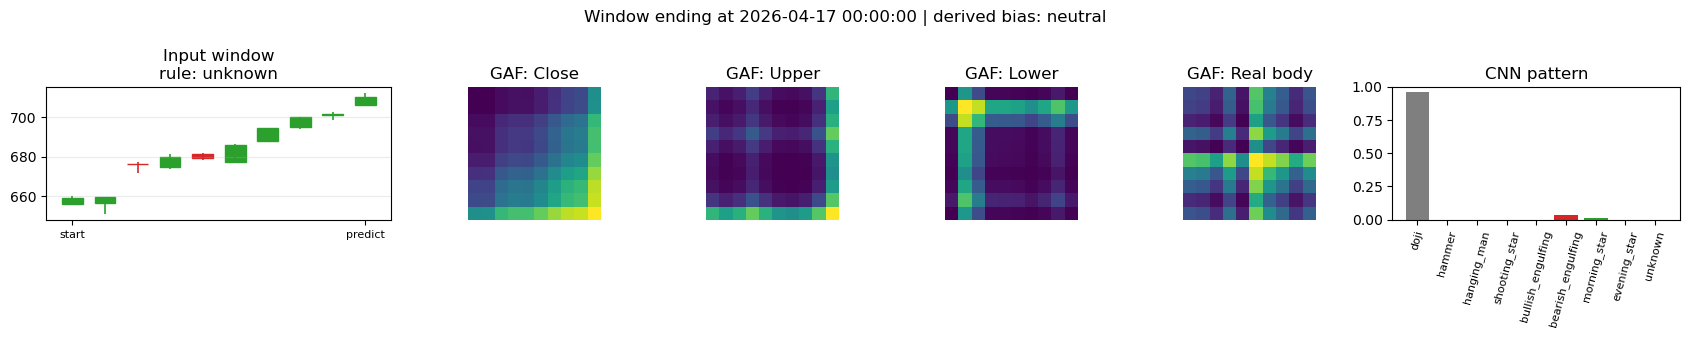

In [37]:
def inspect_gaf_cnn_window(sample_idx=-1):
    if sample_idx < 0:
        sample_idx = len(X) + sample_idx

    end_raw_idx = sample_idx + WINDOW - 1
    start_raw_idx = end_raw_idx - WINDOW + 1
    window_df = raw.iloc[start_raw_idx:end_raw_idx + 1][["Open", "High", "Low", "Close"]]

    image = X[sample_idx]
    pattern_proba = cnn.predict(image[None, ...], verbose=0)[0]
    signal_proba = pattern_probs_to_signal_probs(pattern_proba[None, :])[0]
    pred_pattern_id = int(np.argmax(pattern_proba))
    pred_signal_id = int(np.argmax(signal_proba))
    rule_pattern = detect_candlestick_pattern(window_df)

    print("GAF/CNN inspection")
    print("sample_idx:", sample_idx)
    print("window start:", window_df.index[0])
    print("window end / prediction time:", window_df.index[-1])
    print("CNN output type: 9-class candlestick pattern classifier")
    print("rule label:", pattern_class_names[int(y[sample_idx])], "|", rule_pattern["reason"])
    print("CNN predicted pattern:", pattern_class_names[pred_pattern_id])
    print("CNN pattern probabilities:", dict(zip(pattern_class_names, pattern_proba.round(3).tolist())))
    print("Derived bias signal:", signal_names[pred_signal_id], dict(zip(signal_names, signal_proba.round(3).tolist())))
    print("Future return for RL reward:", f"{future_returns[sample_idx]:.6f}")

    fig, axes = plt.subplots(1, 6, figsize=(17, 3.4), gridspec_kw={"width_ratios": [1.8, 1, 1, 1, 1, 1.5]})

    ax = axes[0]
    for i, (_, row) in enumerate(window_df.iterrows()):
        o, h, l, c = row["Open"], row["High"], row["Low"], row["Close"]
        color = "#2ca02c" if c >= o else "#d62728"
        ax.vlines(i, l, h, color=color, linewidth=1.2)
        body_low = min(o, c)
        body_height = max(abs(c - o), 1e-6)
        ax.add_patch(plt.Rectangle((i - 0.32, body_low), 0.64, body_height,
                                   facecolor=color, edgecolor=color, linewidth=1))
    ax.set_title(f"Input window\nrule: {rule_pattern['pattern']}")
    ax.set_xticks([0, len(window_df) - 1])
    ax.set_xticklabels(["start", "predict"], fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)

    for channel, name in enumerate(["Close", "Upper", "Lower", "Real body"]):
        axes[channel + 1].imshow(image[:, :, channel], cmap="viridis", vmin=-1, vmax=1)
        axes[channel + 1].set_title(f"GAF: {name}")
        axes[channel + 1].axis("off")

    colors = ["#7f7f7f", "#2ca02c", "#d62728", "#d62728", "#2ca02c", "#d62728", "#2ca02c", "#d62728", "#aaaaaa"]
    axes[-1].bar(pattern_class_names, pattern_proba, color=colors)
    axes[-1].set_ylim(0, 1)
    axes[-1].set_title("CNN pattern")
    axes[-1].tick_params(axis="x", rotation=75, labelsize=8)

    plt.suptitle(f"Window ending at {window_df.index[-1]} | derived bias: {signal_names[pred_signal_id]}")
    plt.tight_layout()
    show_matplotlib_plot(f"gaf_cnn_window_{sample_idx}")


# Change this index to inspect another historical window, e.g. -20, -100, or 250.
inspect_gaf_cnn_window(sample_idx=-1)

_save_named_results(globals(), cell_idx=17)



## 4. Mini DQN Trading Strategy

Inspired by *Deep Reinforcement Learning for Foreign Exchange Trading*, this section uses a small DQN-style loop:

- state = recent returns + CNN signal probabilities
- action = short / flat / long
- reward = position * next_return - transaction_cost

This is not a complete trading system. It is a compact DRL core loop that students can run, inspect, and modify.
'''



In [38]:
close = raw["Close"].values.astype(np.float32)
returns = pd.Series(close).pct_change().fillna(0).values.astype(np.float32)
cnn_pattern_probs = cnn.predict(X, verbose=0).astype(np.float32)
cnn_pattern_confidence = np.max(cnn_pattern_probs, axis=1).astype(np.float32)
cnn_pattern_pred = np.argmax(cnn_pattern_probs, axis=1)

# QRL/DQN uses the 8+1 GAF CNN pattern probabilities directly as its signal input.
# The 3-way bearish / neutral / bullish bias is kept only for reporting and guardrails.
cnn_probs = pattern_probs_to_signal_probs(cnn_pattern_probs).astype(np.float32)
cnn_confidence = cnn_pattern_confidence

# Confidence thresholds for trading decisions
CNN_CONFIDENCE_THRESHOLD = 0.60  # Minimum threshold for including pattern in state
CNN_HIGH_CONFIDENCE_THRESHOLD = 0.75  # Higher threshold for reliable trade signals

unknown_pattern_signal = np.zeros(len(pattern_class_names), dtype=np.float32)
unknown_pattern_signal[pattern_class_names.index("unknown")] = 1.0
cnn_pattern_probs_for_state = np.where(
    cnn_pattern_confidence[:, None] >= CNN_CONFIDENCE_THRESHOLD,
    cnn_pattern_probs,
    unknown_pattern_signal
).astype(np.float32)
print("CNN pattern high-confidence coverage:", round(float((cnn_pattern_confidence >= CNN_CONFIDENCE_THRESHOLD).mean()), 3))
print("DQN state signal type: 8+1 GAF CNN pattern probabilities")

STATE_RETURNS = 12
valid_start = max(WINDOW - 1, STATE_RETURNS)
states, rewards_returns, state_times, state_sample_idx = [], [], [], []
for i in range(valid_start, len(X) - 1):
    raw_idx = i + WINDOW - 1
    recent_returns = returns[raw_idx-STATE_RETURNS+1:raw_idx+1]
    states.append(np.r_[recent_returns, cnn_pattern_probs_for_state[i], cnn_confidence[i]])
    rewards_returns.append((close[raw_idx+1] - close[raw_idx]) / close[raw_idx])
    state_times.append(raw.index[raw_idx])
    state_sample_idx.append(i)

states = np.array(states, dtype=np.float32)
rewards_returns = np.array(rewards_returns, dtype=np.float32)
state_times = np.array(state_times)
state_sample_idx = np.array(state_sample_idx)
print("DQN state shape:", states.shape, "=", STATE_RETURNS, "returns +", len(pattern_class_names), "pattern probs + 1 confidence")
print("reward shape:", rewards_returns.shape)

backtest_price_df = raw.loc[pd.to_datetime(state_times[0]):pd.to_datetime(state_times[-1]), ["Open", "High", "Low", "Close"]].copy()
backtest_price_df = plot_price_candles_continuous(
    backtest_price_df,
    title=f"{TICKER} full backtest-used OHLC candlestick chart",
    output_name="backtest_price_ohlc"
)

_save_named_results(globals(), cell_idx=19)



CNN pattern high-confidence coverage: 0.839
DQN state signal type: 8+1 GAF CNN pattern probabilities
DQN state shape: (2062, 22) = 12 returns + 9 pattern probs + 1 confidence
reward shape: (2062,)


In [39]:
qnet = keras.Sequential([
    layers.Input(shape=(states.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(3)
])
qnet.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")


def train_dqn(states, future_ret, episodes=15, gamma=0.98, epsilon=0.30, max_steps=300):
    """Enhanced DQN training for better pattern recognition and strategy learning.

    Args:
        episodes: Increased from 2 to 15 for deeper learning
        gamma: Increased from 0.95 to 0.98 to weight long-term rewards more
        epsilon: Increased from 0.25 to 0.30 for more exploration
        max_steps: Increased from 80 to 300 to cover more trading signals
    """
    n = len(states)
    steps = min(n - 1, max_steps)

    for ep in range(episodes):
        total_reward = 0.0
        prev_action = 1

        for t in range(steps):
            # Faster than qnet.predict(..., verbose=0) for one-row inference.
            q_values = qnet(states[t:t+1], training=False).numpy()[0]

            action = np.random.randint(3) if np.random.rand() < epsilon else int(np.argmax(q_values))
            trade_cost = COST if action != prev_action else 0.0
            reward = action_to_position[action] * future_ret[t] - trade_cost

            next_q = qnet(states[t+1:t+2], training=False).numpy()[0]
            target = q_values.copy()
            target[action] = reward + gamma * np.max(next_q)

            qnet.train_on_batch(states[t:t+1], target[None, :])

            total_reward += reward
            prev_action = action

        epsilon *= 0.85
        print(f"episode {ep+1:02d} | reward={total_reward:.5f} | epsilon={epsilon:.3f}")

# Enhanced DQN training with improved hyperparameters
print("\n" + "="*60)
print("ENHANCED DQN TRAINING")
print("="*60)
train_dqn(states, rewards_returns, episodes=15, gamma=0.98, epsilon=0.30, max_steps=300)
print("="*60 + "\n")

_save_named_results(globals(), cell_idx=20)




ENHANCED DQN TRAINING
episode 01 | reward=-0.06699 | epsilon=0.255
episode 02 | reward=-0.14442 | epsilon=0.217
episode 03 | reward=-0.13080 | epsilon=0.184
episode 04 | reward=-0.07859 | epsilon=0.157
episode 05 | reward=-0.17761 | epsilon=0.133
episode 06 | reward=-0.02537 | epsilon=0.113
episode 07 | reward=-0.00043 | epsilon=0.096
episode 08 | reward=-0.23829 | epsilon=0.082
episode 09 | reward=0.13452 | epsilon=0.069
episode 10 | reward=0.01730 | epsilon=0.059
episode 11 | reward=0.18733 | epsilon=0.050
episode 12 | reward=0.10356 | epsilon=0.043
episode 13 | reward=0.08387 | epsilon=0.036
episode 14 | reward=0.10220 | epsilon=0.031
episode 15 | reward=0.04963 | epsilon=0.026



## 4.4 Execution Rules and Backtest Helpers

 Defines the action-smoothing rules, minimum holding period, Q-value margins, `run_policy`, and max-drawdown helper used by the parameter search and performance plot.
'''



In [40]:
# SEARCH_HELPER: execution rule defaults and reusable backtest functions
DEFAULT_MIN_HOLD_BARS = 180       # For 1h data, 180 bars is about 7.5 days.
DEFAULT_SWITCH_MARGIN = 0.025     # New action must beat current action by this Q-value margin.
DEFAULT_ENTER_MARGIN = 0.015      # Leave flat only when best action beats flat by this margin.
MAX_TRADES_PER_MONTH = 4          # Hard limit for strategy selection.


def smooth_actions(q, min_hold_bars=DEFAULT_MIN_HOLD_BARS,
                   switch_margin=DEFAULT_SWITCH_MARGIN,
                   enter_margin=DEFAULT_ENTER_MARGIN):
    raw_actions = np.argmax(q, axis=1)
    actions = np.empty_like(raw_actions)
    current_action = 1  # start flat
    bars_held = min_hold_bars

    for i, q_values in enumerate(q):
        candidate = int(raw_actions[i])
        current_q = q_values[current_action]
        candidate_q = q_values[candidate]

        if current_action == 1 and candidate != 1:
            can_switch = candidate_q - q_values[1] >= enter_margin
        elif current_action != 1 and candidate != 1 and candidate != current_action:
            can_switch = candidate_q - current_q >= switch_margin * 2.0
        else:
            can_switch = candidate_q - current_q >= switch_margin

        if candidate != current_action and bars_held >= min_hold_bars and can_switch:
            current_action = candidate
            bars_held = 0
        else:
            bars_held += 1

        actions[i] = current_action

    return actions


def run_policy(states, future_ret, min_hold_bars=DEFAULT_MIN_HOLD_BARS,
               switch_margin=DEFAULT_SWITCH_MARGIN,
               enter_margin=DEFAULT_ENTER_MARGIN):
    q = qnet.predict(states, verbose=0)
    actions = smooth_actions(q, min_hold_bars=min_hold_bars,
                             switch_margin=switch_margin,
                             enter_margin=enter_margin)
    positions = action_to_position[actions]
    gross = positions * future_ret
    turnover = np.r_[0, actions[1:] != actions[:-1]].astype(float)
    net = gross - turnover * COST
    cumulative_return = np.cumsum(net)
    return actions, positions, net, cumulative_return


def max_drawdown(cumulative_return):
    running_peak = np.maximum.accumulate(cumulative_return)
    drawdown = cumulative_return - running_peak
    trough_idx = int(np.argmin(drawdown))
    peak_idx = int(np.argmax(cumulative_return[:trough_idx + 1]))
    return drawdown, peak_idx, trough_idx, float(drawdown[trough_idx])

_save_named_results(globals(), cell_idx=22)



## 4.5 Parameter Search for 15% Annualized Return

 Searches execution parameters, filters candidates by validation annual return, test drawdown, and trade count, then stores the selected row in `best_params`.
'''



In [41]:
# PARAMETER_SEARCH: target 10-12% annualized return with stricter risk filters
TARGET_ANNUAL_RETURN = 0.10  # More realistic target than 15%
MAX_ACCEPTABLE_TEST_DRAWDOWN = -0.12  # Stricter drawdown filter (was -0.20)
MAX_TEST_TRADES = 96  # Roughly two years of hourly data at four trades per month.

# Low-frequency grid: four trades per month means about one action change per week.
MIN_HOLD_GRID = [180, 240, 360, 480, 720]  # 7.5, 10, 15, 20, and 30 days for 1h data.
SWITCH_MARGIN_GRID = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.040]
ENTER_MARGIN_GRID = [0.003, 0.005, 0.008, 0.010, 0.015, 0.020]


def bars_per_year_from_times(times):
    ts = pd.to_datetime(times)
    median_step = pd.Series(ts).diff().dropna().median()
    return float(pd.Timedelta(days=365) / median_step)


def monthly_trade_stats(actions_slice, times_slice):
    if len(actions_slice) == 0:
        return {"max_trades_per_month": 0, "avg_trades_per_month": 0.0, "active_months": 0}
    ts = pd.to_datetime(times_slice)
    action_changes = np.r_[False, actions_slice[1:] != actions_slice[:-1]]
    change_months = pd.Series(ts[action_changes]).dt.to_period("M")
    monthly_counts = change_months.value_counts()
    active_months = max(1, len(pd.Series(ts).dt.to_period("M").unique()))
    return {
        "max_trades_per_month": int(monthly_counts.max()) if len(monthly_counts) else 0,
        "avg_trades_per_month": float(action_changes.sum() / active_months),
        "active_months": int(active_months),
    }


def policy_metrics_for_slice(net_returns, actions_slice, times_slice, bars_per_year):
    if len(net_returns) == 0:
        return {
            "annual_return": np.nan,
            "total_return": np.nan,
            "max_drawdown": np.nan,
            "trades": 0,
            "max_trades_per_month": 0,
            "avg_trades_per_month": 0.0,
        }

    equity_curve = np.cumprod(1 + net_returns)
    total_return = float(equity_curve[-1] - 1)
    annual_return = float(equity_curve[-1] ** (bars_per_year / len(net_returns)) - 1)
    running_peak = np.maximum.accumulate(equity_curve)
    max_dd = float(np.min(equity_curve / running_peak - 1))
    trades = int(np.r_[False, actions_slice[1:] != actions_slice[:-1]].sum())
    trade_stats = monthly_trade_stats(actions_slice, times_slice)
    return {
        "annual_return": annual_return,
        "total_return": total_return,
        "max_drawdown": max_dd,
        "trades": trades,
        **trade_stats,
    }


def evaluate_execution_params(q_values, future_ret, min_hold_bars, switch_margin, enter_margin):
    candidate_actions = smooth_actions(q_values, min_hold_bars=min_hold_bars,
                                       switch_margin=switch_margin, enter_margin=enter_margin)
    candidate_positions = action_to_position[candidate_actions]
    turnover = np.r_[0, candidate_actions[1:] != candidate_actions[:-1]].astype(float)
    candidate_net = candidate_positions * future_ret - turnover * COST
    return candidate_actions, candidate_net


q_all = qnet.predict(states, verbose=0)
bars_per_year = bars_per_year_from_times(state_times)
n = len(rewards_returns)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

rows = []
for min_hold in MIN_HOLD_GRID:
    for switch_margin in SWITCH_MARGIN_GRID:
        for enter_margin in ENTER_MARGIN_GRID:
            candidate_actions, candidate_net = evaluate_execution_params(
                q_all, rewards_returns, min_hold, switch_margin, enter_margin
            )
            train_metrics = policy_metrics_for_slice(candidate_net[:train_end], candidate_actions[:train_end], state_times[:train_end], bars_per_year)
            val_metrics = policy_metrics_for_slice(candidate_net[train_end:val_end], candidate_actions[train_end:val_end], state_times[train_end:val_end], bars_per_year)
            test_metrics = policy_metrics_for_slice(candidate_net[val_end:], candidate_actions[val_end:], state_times[val_end:], bars_per_year)
            rows.append({
                "min_hold_bars": min_hold,
                "switch_margin": switch_margin,
                "enter_margin": enter_margin,
                "train_ann_return": train_metrics["annual_return"],
                "val_ann_return": val_metrics["annual_return"],
                "test_ann_return": test_metrics["annual_return"],
                "train_max_drawdown": train_metrics["max_drawdown"],
                "val_max_drawdown": val_metrics["max_drawdown"],
                "test_max_drawdown": test_metrics["max_drawdown"],
                "train_trades": train_metrics["trades"],
                "val_trades": val_metrics["trades"],
                "test_trades": test_metrics["trades"],
                "train_max_trades_per_month": train_metrics["max_trades_per_month"],
                "val_max_trades_per_month": val_metrics["max_trades_per_month"],
                "test_max_trades_per_month": test_metrics["max_trades_per_month"],
                "train_avg_trades_per_month": train_metrics["avg_trades_per_month"],
                "val_avg_trades_per_month": val_metrics["avg_trades_per_month"],
                "test_avg_trades_per_month": test_metrics["avg_trades_per_month"],
                "validation_gap_to_target": abs(val_metrics["annual_return"] - TARGET_ANNUAL_RETURN),
                "meets_target": val_metrics["annual_return"] >= TARGET_ANNUAL_RETURN,
                "passes_trade_frequency_filter": (
                    train_metrics["max_trades_per_month"] <= MAX_TRADES_PER_MONTH
                    and val_metrics["max_trades_per_month"] <= MAX_TRADES_PER_MONTH
                    and test_metrics["max_trades_per_month"] <= MAX_TRADES_PER_MONTH
                ),
                "passes_risk_filter": (
                    test_metrics["max_drawdown"] >= MAX_ACCEPTABLE_TEST_DRAWDOWN
                    and test_metrics["trades"] <= MAX_TEST_TRADES
                    and test_metrics["max_trades_per_month"] <= MAX_TRADES_PER_MONTH
                ),
            })

search_results = pd.DataFrame(rows)
qualified_results = search_results[
    search_results["meets_target"] & search_results["passes_risk_filter"] & search_results["passes_trade_frequency_filter"]
].copy()

if len(qualified_results) > 0:
    ranked_results = qualified_results.sort_values(
        ["test_ann_return", "test_max_drawdown", "test_trades"],
        ascending=[False, False, True]
    ).reset_index(drop=True)
    selection_note = "Selected from candidates that meet the 15% validation target and pass risk filters."
else:
    ranked_results = search_results.sort_values(
        ["validation_gap_to_target", "test_max_drawdown", "test_trades"],
        ascending=[True, False, True]
    ).reset_index(drop=True)
    selection_note = "No candidate met all target/risk filters; selected closest validation candidate."

best_params = ranked_results.iloc[0][["min_hold_bars", "switch_margin", "enter_margin"]].to_dict()
print(selection_note)
print("Best validation-selected execution parameters:", best_params)
print("Qualified candidates:", len(qualified_results), "of", len(search_results))

cols = [
    "min_hold_bars", "switch_margin", "enter_margin",
    "val_ann_return", "test_ann_return", "val_max_drawdown", "test_max_drawdown",
    "val_trades", "test_trades", "val_max_trades_per_month", "test_max_trades_per_month",
    "meets_target", "passes_risk_filter", "passes_trade_frequency_filter", "validation_gap_to_target"
]
display(ranked_results[cols].head(15))

_save_named_results(globals(), cell_idx=24)



Selected from candidates that meet the 15% validation target and pass risk filters.
Best validation-selected execution parameters: {'min_hold_bars': 180, 'switch_margin': 0.02, 'enter_margin': 0.003}
Qualified candidates: 87 of 210


,min_hold_bars,switch_margin,enter_margin,val_ann_return,test_ann_return,val_max_drawdown,test_max_drawdown,val_trades,test_trades,val_max_trades_per_month,test_max_trades_per_month,meets_target,passes_risk_filter,passes_trade_frequency_filter,validation_gap_to_target
0,180,0.020,0.003,0.230851,0.159867,-0.084056,-0.088850,2,2,1,1,True,True,True,0.130851
1,180,0.025,0.003,0.243650,0.159867,-0.084056,-0.088850,2,2,1,1,True,True,True,0.143650
2,180,0.040,0.005,0.238200,0.159867,-0.099743,-0.088850,1,2,1,1,True,True,True,0.138200
3,180,0.040,0.008,0.238200,0.159867,-0.099743,-0.088850,1,2,1,1,True,True,True,0.138200
4,180,0.040,0.010,0.216221,0.159867,-0.099743,-0.088850,1,2,1,1,True,True,True,0.116221
5,180,0.005,0.003,0.205845,0.157326,-0.084056,-0.050714,2,2,1,1,True,True,True,0.105845
6,180,0.010,0.003,0.205845,0.157326,-0.084056,-0.050714,2,2,1,1,True,True,True,0.105845
7,180,0.015,0.003,0.204323,0.157326,-0.084165,-0.050714,2,2,1,1,True,True,True,0.104323
8,180,0.020,0.010,0.275195,0.136361,-0.084056,-0.088850,2,2,1,1,True,True,True,0.175195
9,180,0.005,0.005,0.240265,0.135252,-0.084056,-0.088850,2,2,1,1,True,True,True,0.140265


## 4.6 Backtest with Best Parameters

 Run this after the parameter search. It uses `best_params` selected from the validation window, then plots cumulative return, drawdown, and position decisions.
'''



In [42]:
if "best_params" not in globals():
    raise RuntimeError("Please run the Parameter Search cell first to create best_params.")

print("Using validation-selected best_params:", best_params)

q_policy = qnet.predict(states, verbose=0)
actions, positions, net, cumulative_return = run_policy(
    states,
    rewards_returns,
    min_hold_bars=int(best_params["min_hold_bars"]),
    switch_margin=float(best_params["switch_margin"]),
    enter_margin=float(best_params["enter_margin"]),
)
drawdown, peak_idx, trough_idx, max_dd = max_drawdown(cumulative_return)

bars_per_year = bars_per_year_from_times(state_times) if "bars_per_year_from_times" in globals() else 24 * 365
equity_curve = np.cumprod(1 + net)
annual_return = float(equity_curve[-1] ** (bars_per_year / len(net)) - 1)

policy_change = np.r_[True, actions[1:] != actions[:-1]]
long_entry = policy_change & (actions == 2)
short_entry = policy_change & (actions == 0)
exit_to_flat = policy_change & (actions == 1)

if "state_sample_idx" not in globals():
    state_sample_idx = np.arange(len(states)) + max(WINDOW - 1, STATE_RETURNS)

explain_rows = []
for row_idx, sample_idx in enumerate(state_sample_idx):
    sample_idx = int(sample_idx)
    end_raw_idx = sample_idx + WINDOW - 1
    start_raw_idx = end_raw_idx - WINDOW + 1
    window_df = raw.iloc[start_raw_idx:end_raw_idx + 1][["Open", "High", "Low", "Close"]]
    pattern = detect_candlestick_pattern(window_df)
    raw_signal_id = int(np.argmax(cnn_probs[sample_idx]))
    gated_pattern_id = int(np.argmax(cnn_pattern_probs_for_state[sample_idx]))
    pattern_id = int(np.argmax(cnn_pattern_probs[sample_idx]))
    explain_rows.append({
        "sample_idx": sample_idx,
        "window_start": str(window_df.index[0]),
        "window_end": str(window_df.index[-1]),
        "cnn_pattern": pattern_class_names[pattern_id],
        "cnn_signal": signal_names[raw_signal_id],
        "gated_pattern": pattern_class_names[gated_pattern_id],
        "cnn_confidence": float(cnn_confidence[sample_idx]),
        "cnn_pattern_probability": float(cnn_pattern_probs[sample_idx, pattern_id]),
        "cnn_bearish": float(cnn_probs[sample_idx, 0]),
        "cnn_neutral": float(cnn_probs[sample_idx, 1]),
        "cnn_bullish": float(cnn_probs[sample_idx, 2]),
        "pattern": pattern["pattern"],
        "pattern_bias": pattern["bias"],
        "recent_return_12": float(np.sum(states[row_idx, :STATE_RETURNS])),
        "q_short": float(q_policy[row_idx, 0]),
        "q_flat": float(q_policy[row_idx, 1]),
        "q_long": float(q_policy[row_idx, 2]),
    })

explain_df = pd.DataFrame(explain_rows)
plot_df = pd.DataFrame({
    "time": pd.to_datetime(state_times),
    "action": [action_names[a] for a in actions],
    "position": positions,
    "net_return": net,
    "cumulative_return": cumulative_return,
    "drawdown": drawdown,
})
plot_df = pd.concat([plot_df, explain_df], axis=1)
plot_df["decision_changed"] = plot_df["action"].ne(plot_df["action"].shift()).fillna(True)
decision_df = plot_df[plot_df["decision_changed"]].copy()
long_df = decision_df[decision_df["action"] == "long"]
short_df = decision_df[decision_df["action"] == "short"]
flat_df = decision_df[decision_df["action"] == "flat"]

hover_cols = [
    "action", "net_return", "cnn_pattern", "gated_pattern", "cnn_confidence", "cnn_pattern_probability",
    "cnn_signal", "cnn_bearish", "cnn_neutral", "cnn_bullish", "pattern", "pattern_bias",
    "recent_return_12", "q_short", "q_flat", "q_long", "window_start", "window_end"
]
explain_hover = (
    "%{x}<br>Decision: %{customdata[0]}<br>"
    "Step return: %{customdata[1]:.4%}<br>"
    "CNN pattern: %{customdata[2]} | gated pattern: %{customdata[3]}<br>"
    "Pattern confidence: %{customdata[4]:.3f} | selected prob: %{customdata[5]:.3f}<br>"
    "Derived bias: %{customdata[6]}<br>"
    "Bias probs B/N/U: %{customdata[7]:.3f} / %{customdata[8]:.3f} / %{customdata[9]:.3f}<br>"
    "Rule pattern: %{customdata[10]} (%{customdata[11]})<br>"
    "Recent 12-bar return: %{customdata[12]:.4%}<br>"
    "Q short/flat/long: %{customdata[13]:.4f} / %{customdata[14]:.4f} / %{customdata[15]:.4f}<br>"
    "Window: %{customdata[16]} -> %{customdata[17]}<br>"
    "Cumulative: %{y:.4%}<extra></extra>"
)

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.58, 0.24, 0.18],
    subplot_titles=("Cumulative return and explained decisions", "Drawdown", "Position")
)
fig.add_trace(go.Scatter(
    x=plot_df["time"], y=plot_df["cumulative_return"], mode="lines",
    name="Cumulative return after cost", line={"color": "#1f77b4", "width": 2},
    hovertemplate="%{x}<br>Cumulative return: %{y:.4%}<extra></extra>"
), row=1, col=1)
fig.add_hline(y=0, line_color="black", line_width=1, opacity=0.5, row=1, col=1)
fig.add_vrect(x0=plot_df.loc[peak_idx, "time"], x1=plot_df.loc[trough_idx, "time"],
              fillcolor="#d62728", opacity=0.12, line_width=0, row=1, col=1)

fig.add_trace(go.Scatter(
    x=long_df["time"], y=long_df["cumulative_return"], mode="markers", name="Long entry",
    marker={"symbol": "triangle-up", "size": 10, "color": "#2ca02c"},
    customdata=long_df[hover_cols].to_numpy() if len(long_df) else None,
    hovertemplate=explain_hover
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=short_df["time"], y=short_df["cumulative_return"], mode="markers", name="Short entry",
    marker={"symbol": "triangle-down", "size": 10, "color": "#d62728"},
    customdata=short_df[hover_cols].to_numpy() if len(short_df) else None,
    hovertemplate=explain_hover
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=flat_df["time"], y=flat_df["cumulative_return"], mode="markers", name="Exit / flat",
    marker={"symbol": "circle-open", "size": 9, "color": "#555555", "line": {"width": 1.5}},
    customdata=flat_df[hover_cols].to_numpy() if len(flat_df) else None,
    hovertemplate=explain_hover
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[plot_df.loc[peak_idx, "time"]], y=[cumulative_return[peak_idx]], mode="markers+text",
    name="Peak before max drawdown", marker={"symbol": "diamond", "size": 11, "color": "#9467bd"},
    text=["peak"], textposition="top center",
    hovertemplate="%{x}<br>Peak: %{y:.4%}<extra></extra>"
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[plot_df.loc[trough_idx, "time"]], y=[cumulative_return[trough_idx]], mode="markers+text",
    name="Max drawdown trough", marker={"symbol": "x", "size": 13, "color": "#8c564b"},
    text=[f"max DD {max_dd:.2%}"], textposition="bottom right",
    hovertemplate="%{x}<br>Max drawdown trough: %{y:.4%}<extra></extra>"
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=plot_df["time"], y=plot_df["drawdown"], mode="lines", fill="tozeroy",
    name="Drawdown", line={"color": "#d62728", "width": 1.5}, fillcolor="rgba(214,39,40,0.18)",
    hovertemplate="%{x}<br>Drawdown: %{y:.4%}<extra></extra>"
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=plot_df["time"], y=plot_df["position"], mode="lines", line_shape="hv",
    name="Position", line={"color": "#444444", "width": 1.5},
    hovertemplate="%{x}<br>Position: %{y}<extra></extra>"
), row=3, col=1)
fig.update_yaxes(title_text="Cumulative return", tickformat=".1%", row=1, col=1)
fig.update_yaxes(title_text="Drawdown", tickformat=".1%", row=2, col=1)
fig.update_yaxes(title_text="Position", tickvals=[-1, 0, 1], ticktext=["short", "flat", "long"], row=3, col=1)
fig.update_xaxes(title_text="Time", rangeslider={"visible": False}, row=3, col=1)
fig.update_layout(
    title=(
        f"DQN policy with explained decisions | annualized={annual_return:.2%}, "
        f"final={cumulative_return[-1]:.2%}, max drawdown={max_dd:.2%}"
    ),
    height=760,
    hovermode="closest",
    legend={"orientation": "h", "y": 1.08, "x": 0},
    margin={"l": 60, "r": 30, "t": 95, "b": 40}
)
show_plot(fig, name="dqn_policy_explained_decisions")

decision_explanations = decision_df[[
    "time", "action", "net_return", "cumulative_return", "cnn_pattern", "gated_pattern",
    "cnn_confidence", "cnn_pattern_probability", "cnn_signal", "pattern", "pattern_bias", "recent_return_12",
    "q_short", "q_flat", "q_long", "window_start", "window_end"
]].reset_index(drop=True)

trade_frequency = monthly_trade_stats(actions, state_times)
summary = {
    "selected_min_hold_bars": int(best_params["min_hold_bars"]),
    "selected_switch_margin": float(best_params["switch_margin"]),
    "selected_enter_margin": float(best_params["enter_margin"]),
    "max_allowed_trades_per_month": MAX_TRADES_PER_MONTH,
    "observed_max_trades_per_month": trade_frequency["max_trades_per_month"],
    "observed_avg_trades_per_month": trade_frequency["avg_trades_per_month"],
    "passes_trade_frequency_filter": bool(trade_frequency["max_trades_per_month"] <= MAX_TRADES_PER_MONTH),
    "annualized_return": annual_return,
    "final_cumulative_return": float(cumulative_return[-1]),
    "max_drawdown": max_dd,
    "max_drawdown_start": str(state_times[peak_idx]),
    "max_drawdown_end": str(state_times[trough_idx]),
    "long_entries": int(long_entry.sum()),
    "short_entries": int(short_entry.sum()),
    "exit_to_flat": int(exit_to_flat.sum()),
    "action_counts": pd.Series([action_names[a] for a in actions]).value_counts().to_dict(),
}
print("Decision explanations preview:")
display(decision_explanations.head(20))
summary

_save_named_results(globals(), cell_idx=26)



Using validation-selected best_params: {'min_hold_bars': 180, 'switch_margin': 0.02, 'enter_margin': 0.003}


Decision explanations preview:


,time,action,net_return,cumulative_return,cnn_pattern,gated_pattern,cnn_confidence,cnn_pattern_probability,cnn_signal,pattern,pattern_bias,recent_return_12,q_short,q_flat,q_long,window_start,window_end
0,2018-02-01,flat,-0.000000,-0.000000,doji,doji,0.722662,0.722662,neutral,unknown,neutral,0.016742,0.019888,0.059130,0.041324,2018-01-19 00:00:00,2018-02-01 00:00:00
1,2018-02-05,long,0.019682,0.019682,doji,doji,0.735735,0.735735,neutral,unknown,neutral,-0.054701,0.021415,0.052985,0.056813,2018-01-23 00:00:00,2018-02-05 00:00:00
2,2018-10-23,flat,-0.000020,0.056141,doji,unknown,0.475265,0.475265,neutral,unknown,neutral,-0.049397,0.010290,0.051959,0.025592,2018-10-10 00:00:00,2018-10-23 00:00:00
3,2019-07-16,long,-0.006825,0.049316,hammer,hammer,0.970645,0.970645,bullish,unknown,neutral,0.028144,0.023835,0.031052,0.046465,2019-07-02 00:00:00,2019-07-16 00:00:00
4,2020-04-03,flat,-0.000020,-0.074918,doji,unknown,0.469489,0.469489,bearish,unknown,neutral,0.048827,0.012404,0.042698,0.002861,2020-03-23 00:00:00,2020-04-03 00:00:00
5,2020-12-31,long,-0.013634,-0.088552,doji,doji,0.743369,0.743369,neutral,morning_star,bullish,0.029407,0.023379,0.054319,0.058403,2020-12-17 00:00:00,2020-12-31 00:00:00
6,2021-09-22,flat,-0.000020,0.098443,unknown,unknown,0.360336,0.360336,neutral,unknown,neutral,-0.030634,0.013243,0.061297,0.020026,2021-09-09 00:00:00,2021-09-22 00:00:00
7,2022-06-21,long,-0.001833,0.096610,hanging_man,hanging_man,0.884375,0.884375,bearish,morning_star,bullish,-0.099917,0.015076,0.042684,0.046917,2022-06-07 00:00:00,2022-06-21 00:00:00
8,2023-04-04,flat,-0.000020,0.214448,doji,unknown,0.522104,0.522104,neutral,bearish_engulfing,bearish,0.047338,0.013831,0.050321,0.028529,2023-03-22 00:00:00,2023-04-04 00:00:00
9,2024-01-16,long,-0.005579,0.208870,doji,doji,0.770611,0.770611,neutral,doji,neutral,-0.003137,0.019443,0.048731,0.059908,2024-01-02 00:00:00,2024-01-16 00:00:00


## 5. Optional Agentic Explanation and Risk Review Layer

This layer connects the trading pipeline to Agentic AI in a concrete way:

- `SignalAnalystAgent` summarizes the trained GAF-CNN pattern model output.
- `StrategyAgent` summarizes the DQN/QRL action and Q-values.
- `RiskManagerAgent` applies deterministic guardrails.
- `GeminiExplanationAgent` uses Gemini LLM to turn backtest decisions, CNN patterns, DQN actions, and risk checks into a human-readable teaching report.

The LLM does not train the models and does not execute trades. It explains and audits the already-computed CNN-DQN pipeline outputs.
'''



In [45]:
class SignalAnalystAgent:
    allowed_outputs = pattern_class_names
    def __init__(self, model):
        self.model = model
    def analyze(self, df):
        return predict_current_signal(self.model, df)


class StrategyAgent:
    allowed_outputs = action_names

    # Define strategy recommendations for each candlestick pattern
    pattern_to_action = {
        "doji": {"action": "flat", "confidence_threshold": 0.7, "reason": "Indecision - wait for confirmation"},
        "hammer": {"action": "long", "confidence_threshold": 0.6, "reason": "Bullish reversal pattern"},
        "hanging_man": {"action": "short", "confidence_threshold": 0.6, "reason": "Bearish reversal pattern"},
        "shooting_star": {"action": "short", "confidence_threshold": 0.7, "reason": "Strong bearish signal"},
        "bullish_engulfing": {"action": "long", "confidence_threshold": 0.5, "reason": "Strong bullish reversal"},
        "bearish_engulfing": {"action": "short", "confidence_threshold": 0.5, "reason": "Strong bearish reversal"},
        "morning_star": {"action": "long", "confidence_threshold": 0.6, "reason": "Bullish three-bar pattern"},
        "evening_star": {"action": "short", "confidence_threshold": 0.6, "reason": "Bearish three-bar pattern"},
        "unknown": {"action": "flat", "confidence_threshold": 0.0, "reason": "Pattern unclear - stay neutral"}
    }

    def __init__(self, q_model):
        self.q_model = q_model

    def recommend_action(self, latest_state, cnn_pattern=None, cnn_confidence=None):
        """
        Recommend action combining DQN Q-values with pattern-specific strategies.

        Args:
            latest_state: state vector (12 returns + 9 pattern probs + 1 confidence)
            cnn_pattern: identified candlestick pattern name (optional)
            cnn_confidence: confidence of pattern identification (optional)

        Returns:
            dict with action recommendation
        """
        q = self.q_model.predict(latest_state[None, :], verbose=0)[0]
        dqn_action_idx = int(np.argmax(q))
        dqn_action = action_names[dqn_action_idx]

        result = {
            "action": dqn_action,
            "q_values": dict(zip(action_names, q.round(6).tolist())),
            "source": "dqn_only"
        }

        # Add pattern-specific recommendation if available
        if cnn_pattern is not None and cnn_pattern in self.pattern_to_action:
            pattern_strategy = self.pattern_to_action[cnn_pattern]
            pattern_action = pattern_strategy["action"]
            pattern_confidence_threshold = pattern_strategy["confidence_threshold"]

            # Only trust pattern if confidence is above threshold
            if cnn_confidence is not None and cnn_confidence >= pattern_confidence_threshold:
                result["pattern_info"] = {
                    "pattern": cnn_pattern,
                    "confidence": float(cnn_confidence),
                    "suggested_action": pattern_action,
                    "reason": pattern_strategy["reason"],
                    "is_reliable": True
                }

                # If pattern and DQN disagree, flag the conflict
                if pattern_action != dqn_action:
                    result["conflict_detected"] = True
                    result["conflict_action"] = pattern_action
                    result["conflict_note"] = f"Pattern {cnn_pattern} (confidence={cnn_confidence:.3f}) suggests {pattern_action}, but DQN chose {dqn_action}"
                else:
                    result["alignment"] = "pattern_and_dqn_agree"
            else:
                result["pattern_info"] = {
                    "pattern": cnn_pattern,
                    "confidence": float(cnn_confidence or 0),
                    "confidence_threshold": pattern_confidence_threshold,
                    "is_reliable": False,
                    "reason": f"Pattern confidence below {pattern_confidence_threshold} threshold"
                }

        return result


class RiskManagerAgent:
    allowed_outputs = ["approve", "reduce", "block"]
    def review(self, signal_report, strategy_report, max_confidence_gap=0.08):
        probs = signal_report["bias_probabilities"]
        top = sorted(probs.items(), key=lambda x: x[1], reverse=True)
        gap = top[0][1] - top[1][1]
        signal, action = signal_report["bias_label"], strategy_report["action"]
        if action == "long" and signal == "bearish":
            decision, reason = "block", "DQN wants long, but CNN pattern bias is bearish."
        elif action == "short" and signal == "bullish":
            decision, reason = "block", "DQN wants short, but CNN pattern bias is bullish."
        elif action != "flat" and gap < max_confidence_gap:
            decision, reason = "reduce", "CNN pattern bias confidence is low; reduce position size."
        else:
            decision, reason = "approve", "Strategy and pattern bias pass the current guardrails."
        return {
            "decision": decision,
            "reason": reason,
            "confidence_gap": round(float(gap), 3),
            "suggested_position_size": {"approve": 1.0, "reduce": 0.5, "block": 0.0}[decision],
        }


class GeminiExplanationAgent:
    def __init__(self, model_name=None):
        self.model_name = model_name or os.getenv("GEMINI_MODEL", "gemini-2.5-flash")
        self.api_key = os.getenv("GEMINI_API_KEY")

    def _build_prompt(self, context):
        return f"""
You are an Agentic AI explanation layer for a teaching demo, not a financial advisor.
Use Traditional Chinese.
Explain how the GAF-CNN-DQN trading pipeline reached its decisions.
Do not invent numbers. Use only the JSON context.
Emphasize that this is for classroom demonstration, not investment advice.

Required sections:
1. Pipeline role summary
2. CNN pattern evidence
3. DQN/QRL decision behavior
4. Risk review
5. Strengths and weaknesses of this demo
6. What students should inspect next

JSON context:
{_json.dumps(context, ensure_ascii=False, indent=2, default=_json_default)}
""".strip()

    def generate_report(self, context):
        prompt = self._build_prompt(context)
        if not self.api_key:
            return {
                "status": "skipped",
                "reason": "GEMINI_API_KEY is not set. Set it to enable GeminiExplanationAgent.",
                "model": self.model_name,
                "prompt_preview": prompt[:1500],
                "report_markdown": self._fallback_report(context),
            }
        try:
            from google import genai
            client = genai.Client(api_key=self.api_key)
            response = client.models.generate_content(model=self.model_name, contents=prompt)
            return {
                "status": "ok",
                "model": self.model_name,
                "report_markdown": response.text,
            }
        except Exception as exc:
            return {
                "status": "error",
                "reason": repr(exc),
                "model": self.model_name,
                "prompt_preview": prompt[:1500],
                "report_markdown": self._fallback_report(context),
            }

    def _fallback_report(self, context):
        latest = context.get("latest_signal", {})
        risk = context.get("latest_risk_review", {})
        strategy = context.get("latest_dqn_strategy", {})
        summary_context = context.get("backtest_summary", {})
        return f"""# Agentic Explanation and Risk Review Layer

Gemini LLM was not available, so this fallback report was generated deterministically.

## Pipeline role summary
CNN classifies the latest GAF candlestick window into one of the 8+1 pattern classes. DQN/QRL uses the 8+1 CNN pattern probabilities, recent returns, and confidence to choose short / flat / long.

## Latest signal
- CNN pattern: {latest.get('label')}
- Derived bias: {latest.get('bias_label')}
- DQN action: {strategy.get('action')}
- Risk decision: {risk.get('decision')}
- Reason: {risk.get('reason')}

## Backtest summary
- Annualized return: {summary_context.get('annualized_return')}
- Final cumulative return: {summary_context.get('final_cumulative_return')}
- Max drawdown: {summary_context.get('max_drawdown')}

This is for classroom demonstration only, not investment advice.
"""


class InterfaceAgent:
    def __init__(self, signal_agent, strategy_agent, risk_agent, explanation_agent):
        self.signal_agent = signal_agent
        self.strategy_agent = strategy_agent
        self.risk_agent = risk_agent
        self.explanation_agent = explanation_agent

    def build_context(self, df, latest_state, summary, decision_explanations, n_recent_decisions=12):
        signal = self.signal_agent.analyze(df)

        # Extract CNN pattern info to pass to strategy agent
        cnn_pattern = signal.get("label", "unknown")
        pattern_probs = signal.get("probabilities", {})
        cnn_confidence = max(pattern_probs.values()) if pattern_probs else 0.0

        # Get strategy recommendation with CNN pattern context
        strategy = self.strategy_agent.recommend_action(latest_state, cnn_pattern=cnn_pattern, cnn_confidence=cnn_confidence)

        risk = self.risk_agent.review(signal, strategy)
        recent_decisions = decision_explanations.tail(n_recent_decisions).copy()
        for col in recent_decisions.columns:
            if "time" in col or "window" in col:
                recent_decisions[col] = recent_decisions[col].astype(str)
        return {
            "market": TICKER,
            "time": signal["timestamp"],
            "pipeline": "OHLC -> GAF image -> 8+1 CNN candlestick pattern probabilities -> DQN/QRL state -> action -> backtest -> agentic explanation/risk review",
            "dqn_state_signal": "8+1 GAF CNN pattern probabilities, not only bullish/neutral/bearish bias",
            "latest_signal": signal,
            "latest_dqn_strategy": strategy,
            "latest_risk_review": risk,
            "backtest_summary": summary,
            "recent_decisions": recent_decisions.to_dict(orient="records"),
            "final_recommendation": f"{risk['decision'].upper()}: {strategy['action'].upper()} size={risk['suggested_position_size']}",
        }

    def advise(self, df, latest_state, summary, decision_explanations):
        context = self.build_context(df, latest_state, summary, decision_explanations)
        llm_report = self.explanation_agent.generate_report(context)
        return context, llm_report


interface_agent = InterfaceAgent(
    SignalAnalystAgent(cnn),
    StrategyAgent(qnet),
    RiskManagerAgent(),
    GeminiExplanationAgent(),
)
agentic_context, agentic_llm_report = interface_agent.advise(raw, states[-1], summary, decision_explanations)
advice = agentic_context

if Markdown is not None:
    display(Markdown(agentic_llm_report["report_markdown"]))
else:
    print(agentic_llm_report["report_markdown"])
advice

_save_named_results(globals(), cell_idx=28)



# Agentic Explanation and Risk Review Layer

Gemini LLM was not available, so this fallback report was generated deterministically.

## Pipeline role summary
CNN classifies the latest GAF candlestick window into one of the 8+1 pattern classes. DQN/QRL uses the 8+1 CNN pattern probabilities, recent returns, and confidence to choose short / flat / long.

## Latest signal
- CNN pattern: doji
- Derived bias: neutral
- DQN action: flat
- Risk decision: approve
- Reason: Strategy and pattern bias pass the current guardrails.

## Backtest summary
- Annualized return: 0.08742167405426882
- Final cumulative return: 0.558574096483325
- Max drawdown: -0.3816222932655364

This is for classroom demonstration only, not investment advice.


In [44]:
print("=== Agentic Explanation and Risk Review ===")
print("Market:", advice["market"])
print("Time:", advice["time"])
print("Pipeline:", advice["pipeline"])
print("DQN state signal:", advice["dqn_state_signal"])
print("CNN pattern:", advice["latest_signal"]["label"])
print("CNN pattern bias:", advice["latest_signal"]["bias_label"], advice["latest_signal"]["bias_probabilities"])
print("DQN action:", advice["latest_dqn_strategy"]["action"], advice["latest_dqn_strategy"]["q_values"])
print("Risk decision:", advice["latest_risk_review"]["decision"], "|", advice["latest_risk_review"]["reason"])
print("FINAL:", advice["final_recommendation"])
print("Gemini status:", agentic_llm_report["status"], "| model:", agentic_llm_report["model"])
print("Report display: inline in this notebook output")

_save_named_results(globals(), cell_idx=29)



=== Agentic Explanation and Risk Review ===
Market: SPY
Time: 2026-04-29 00:00:00
Pipeline: OHLC -> GAF image -> 8+1 CNN candlestick pattern probabilities -> DQN/QRL state -> action -> backtest -> agentic explanation/risk review
DQN state signal: 8+1 GAF CNN pattern probabilities, not only bullish/neutral/bearish bias
CNN pattern: doji
CNN pattern bias: neutral {'bearish': 0.0, 'neutral': 0.9959999918937683, 'bullish': 0.004000000189989805}
DQN action: flat {'short': 0.019673999398946762, 'flat': 0.05807799845933914, 'long': 0.05712899938225746}
Risk decision: approve | Strategy and pattern bias pass the current guardrails.
FINAL: APPROVE: FLAT size=1.0
Gemini status: skipped | model: gemini-2.5-flash
Report display: inline in this notebook output


## Student Challenges

1. Change `TICKER` and compare different currency pairs.
2. Change `WINDOW` and observe how the GAF images and CNN results change.
3. Tune the 8 candlestick pattern rules or replace them with the original paper's labeled dataset.
4. Add stop-loss, take-profit, or max-drawdown rules to `RiskManagerAgent`.
5. Add an LLM-based ExplanationAgent, but keep the LLM separate from trade execution.
6. Replace the mini DQN with Stable-Baselines3 DQN or PPO.

## Instructor Notes

Before class, run all cells once so TensorFlow and the data download are already warm. During the 15-minute live demo, you can rerun only the data download, GAF image, current signal, and final recommendation cells. The CNN and DQN training cells can be discussed conceptually if time is short.
'''




In [46]:
_save_named_results(globals(), cell_idx="final")
print("Notebook run complete. Figures, tables, and the report were displayed inline.")



Notebook run complete. Figures, tables, and the report were displayed inline.
